# DS 4320 Project 1: Detecting AI-Generated Personas

Short paragrah here



Karen Guzman

Sae3gg

DOI

Press Release

Data

Pipeline

License

## Problem Definition

### Problem

General Problem: Detecting AI-generated images/text/etc

Specific Problem: Detecting AI-generated personas in Social Media Profiles

### Rationale for refinement

Detecting AI-generated media is becoming harder, but the harm varies a lot by context. AI-generated personas are especially dangerous because victims face real financial or emotional damage. AI-written phishing emails can have more severe consequences than an AI-generated response to an interview application. This refinement on intentional  harm on people is important because it creates outlets for harm on real human life. Social media was chosen as the prime subject because of the growing cases of AI-generated personas.

### Motivation for this Project

This project is motivated by the need to detect AI-generated personas in social media. Fake profiles can have a variety of elements, including an AI-generated photo, which might not always be of a person. The image data paired with account metadata and profile activity can be very telling. A Dataset containing these elements would be essential to solving this problem.

### Press Release Link



---



## Domain Exposition

### Terminology

1. **EXIF Data** — metadata embedded in photo files by cameras/phones (timestamp, device model, GPS). AI images typically lack this entirely

2. **Laplacian Variance** — a measure of image sharpness; low values mean blurry
Noise Level — random pixel-level variation in an image; real photos have natural camera noise, AI images often don't

3. **Saturation** — intensity of colors in an image

4. **Pixel Distribution** — how color/brightness values are spread across an image

5. **Follower Ratio** — user_follower_count / user_following_count; fake accounts often follow many but have few followers back

6. **Profile Completeness** — how filled-out a profile is (has pic, has bio, post count); fake accounts tend to be sparse

### Domain

My project lives at the intersection of cybersecurity and digital identity; it resides within the field of online harm detection, specifically social media. AI technology makes it easier to create convincing fake personas. This project directly addresses this potential danger, as AI-generated accounts could be used to deceive real users, potentionally enabling financial or emotional harm to others on a given platform. Social media safety would be at the core of this project.

### Background Reading

[Project 1 Background Reading Files](https://1drv.ms/f/c/fbb5975494ef3dae/IgDgNuMAxWXUSJDz-UbUBrbiAXMCOkcpQYHOGAGHodA1ifk?e=umWNUZ)

### Summary Table

| Title | Summary | Link |
|-------|---------|------|
| Generative AI personas considered harmful? Putting forth twenty challenges of algorithmic user representation in human-computer interaction | Examines the potential challenges that generative AI personas could have on stakeholder groups. There are multiple ways that harm can be done to society, for example, propagating biases, erosion of authentic user research practices, or misinformed design decisions based on these synthetically designed personas. | [Link](https://1drv.ms/t/c/fbb5975494ef3dae/IQB7wzEkzRlLSbT81sgV26jWAQbuTBvnnz3lQ3lqW7ukrVA?e=cDyJSv) |
| Digital Doppelgangers and AI Personas | Defines a digital doppelganger and how AI personas are created. This article covers mimicry mechanics, deepfake technology, and the effects of these personas on society. | [Link](https://1drv.ms/t/c/fbb5975494ef3dae/IQAi5MNvafWZQrCwQHI5HczRATFf3DloCNa-DmEp6iLvEAs?e=iQNx9R) |
| Risks of AI Mirror Social Media | Covers how AI is being used in social media; the article focuses on chatbots and their data collection. It also discusses the challenges of impulsivity and persuasion techniques used by chatbots that increase risk for both children and adults. | [Link](https://1drv.ms/t/c/fbb5975494ef3dae/IQDrdWoYYfgsTp97Ix5aOw4EAXvNFdvi31jo3PY9XEf41Ok?e=EcBGFJ) |
| Navigating the Risks of Artificial Intelligence on the Digital News Landscape | Focuses on the broader topic of disadvantages of AI in social media. Includes concerns of privacy, algorithm bias, job displacement, and more. | [Link](https://1drv.ms/t/c/fbb5975494ef3dae/IQDHxF6SZ5UDRoLoCmTuEMSaAfQ14gMkILduHszsvWPivO4?e=AuK5PP) |
| Social media platforms aren't doing enough to stop harmful AI bots, research finds | While this does not focus on AI-generated personas specifically, it discusses a broader topic of AI-generated content on social media: bots. Their study consisted of attempting to launch bots on various social media sites. | [Link](https://1drv.ms/t/c/fbb5975494ef3dae/IQDtrucQrTtNS5HRiDYOm8YdAVUNnxDevdEV9AMWQ_YU5OY?e=nFz5yx) |



---



## Press Release

Faces: https://www.kaggle.com/datasets/kaustubhdhote/human-faces-dataset?resource=download

Account data: https://github.com/fcakyon/instafake-dataset

In [10]:
from google.colab import userdata
import os
import json
import pandas as pd

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_TOKEN')

import kagglehub

# Download latest version
path = kagglehub.dataset_download("kaustubhdhote/human-faces-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'human-faces-dataset' dataset.
Path to dataset files: /kaggle/input/human-faces-dataset


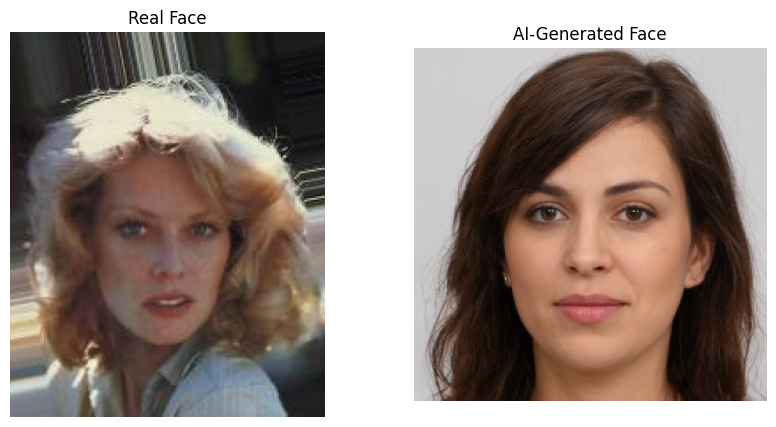

In [17]:
#load face images
import matplotlib.pyplot as plt
from PIL import Image

real_path = os.path.join(path, "Human Faces Dataset", "Real Images")
ai_path = os.path.join(path, "Human Faces Dataset", "AI-Generated Images")

real_img = Image.open(os.path.join(real_path, os.listdir(real_path)[0]))
ai_img = Image.open(os.path.join(ai_path, os.listdir(ai_path)[0]))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(real_img)
axes[0].set_title("Real Face")
axes[0].axis('off')
axes[1].imshow(ai_img)
axes[1].set_title("AI-Generated Face")
axes[1].axis('off')
plt.show()

In [18]:
#load instafake account data
import json
import pandas as pd

with open("/content/fakeAccountData.json") as f:
    fake_data = json.load(f)
for record in fake_data:
    record['label'] = 'fake'

with open("/content/realAccountData.json") as f:
    real_data = json.load(f)
for record in real_data:
    record['label'] = 'real'

df_accounts = pd.DataFrame(fake_data + real_data)
print(df_accounts.shape)
print(df_accounts.head())

(1194, 10)
   userFollowerCount  userFollowingCount  userBiographyLength  userMediaCount  \
0                 25                1937                    0               0   
1                324                4122                    0               0   
2                 15                 399                    0               0   
3                 14                 107                    0               1   
4                264                4651                    0               0   

   userHasProfilPic  userIsPrivate  usernameDigitCount  usernameLength  \
0                 1              1                   0              10   
1                 1              0                   4              15   
2                 0              0                   3              12   
3                 1              0                   1              10   
4                 1              0                   0              14   

   isFake label  
0       1  fake  
1       1  fake  
2  

In [19]:
#pair each account with a face image
import random

real_faces_list = os.listdir(real_path)
ai_faces_list = os.listdir(ai_path)

def assign_face(row):
    if row['label'] == 'real':
        return random.choice(real_faces_list)
    else:
        return random.choice(ai_faces_list)

df_accounts['profile_pic'] = df_accounts.apply(assign_face, axis=1)

print("Total accounts:", len(df_accounts))
print(df_accounts['label'].value_counts())
print(df_accounts[['label', 'profile_pic']].head(10))

Total accounts: 1194
label
real    994
fake    200
Name: count, dtype: int64
  label profile_pic
0  fake  000634.jpg
1  fake  000177.jpg
2  fake  001576.jpg
3  fake  003527.jpg
4  fake  002874.jpg
5  fake  002343.jpg
6  fake  003586.jpg
7  fake  001453.jpg
8  fake  004216.jpg
9  fake  000712.jpg


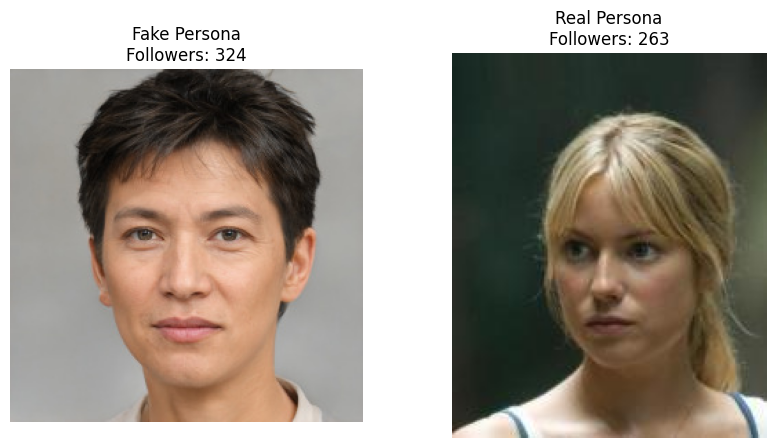

In [26]:
#display a sample combined persona
sample_fake = df_accounts[df_accounts['label'] == 'fake'].iloc[1]
sample_real = df_accounts[df_accounts['label'] == 'real'].iloc[1]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

fake_img = Image.open(os.path.join(ai_path, sample_fake['profile_pic']))
axes[0].imshow(fake_img)
axes[0].set_title(f"Fake Persona\nFollowers: {sample_fake['userFollowerCount']}")
axes[0].axis('off')

real_img = Image.open(os.path.join(real_path, sample_real['profile_pic']))
axes[1].imshow(real_img)
axes[1].set_title(f"Real Persona\nFollowers: {sample_real['userFollowerCount']}")
axes[1].axis('off')

plt.show()

In [23]:
print(df_accounts.columns.tolist())
print(df_accounts.dtypes)
print(df_accounts.describe())

['userFollowerCount', 'userFollowingCount', 'userBiographyLength', 'userMediaCount', 'userHasProfilPic', 'userIsPrivate', 'usernameDigitCount', 'usernameLength', 'isFake', 'label', 'profile_pic']
userFollowerCount       int64
userFollowingCount      int64
userBiographyLength     int64
userMediaCount          int64
userHasProfilPic        int64
userIsPrivate           int64
usernameDigitCount      int64
usernameLength          int64
isFake                  int64
label                  object
profile_pic            object
dtype: object
       userFollowerCount  userFollowingCount  userBiographyLength  \
count        1194.000000         1194.000000          1194.000000   
mean          369.095477          744.261307            22.847571   
std           372.775741         1032.526420            33.492868   
min             0.000000            0.000000             0.000000   
25%           152.000000          267.000000             0.000000   
50%           304.000000          449.000000  